# Debugging

In [11]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:llama-3.1-8b-instant')
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1100be1b0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x111857950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [17]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
# graph with tool call

@tool
def add(a:float, b:float) -> float:
    """Adding two number"""
    return a + b

tools = [add]

llm_with_tool = llm.bind_tools([add])

def call_llm_model(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}


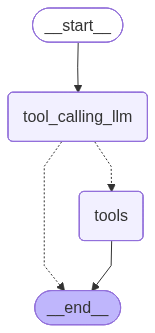

In [19]:
# stategraph

# nodes
builder = StateGraph(State)
builder.add_node('tools', ToolNode(tools=tools))
builder.add_node('tool_calling_llm', call_llm_model)

# edges
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    tools_condition
)
builder.add_edge('tools', END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response = graph.invoke({'messages': 'what is quantitative machine learning?'})

In [22]:
response['messages'][-1].content

'<brave_search> Quantitative machine learning'

In [23]:
response = graph.invoke({'messages': 'what is 34+90??'})

In [24]:
response

{'messages': [HumanMessage(content='what is 34+90??', additional_kwargs={}, response_metadata={}, id='4c9ab192-f0be-4cb0-8f04-0b96640153e1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '53y6v7psx', 'function': {'arguments': '{"a":34,"b":90}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 219, 'total_tokens': 237, 'completion_time': 0.032287225, 'completion_tokens_details': None, 'prompt_time': 0.017000055, 'prompt_tokens_details': None, 'queue_time': 0.053390581, 'total_time': 0.04928728}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f279d-7188-7691-af0b-5578e9d45da7-0', tool_calls=[{'name': 'add', 'args': {'a': 34, 'b': 90}, 'id': '53y6v7psx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 219, 'output_tokens': 18,